## Load Packages


In [1]:
using Pkg
Pkg.activate(".")


  Activating project at `~/RxGP.jl/examples`


In [2]:
using RxInfer, RxGP
using Random, LinearAlgebra, StatsFuns, Distributions
using KernelFunctions
using Optim, ForwardDiff, Flux
using Plots

import KernelFunctions: SqExponentialKernel, with_lengthscale, kernelmatrix


## Generate Data


In [4]:
Random.seed!(3)

xmin, xmax = -4, 4
N = 50
precision = 100

xtrain = sort(rand(Uniform(xmin, xmax), N))
xtrain_vv = [[x] for x in xtrain]

xtest = collect(range(xmin - 0.1, xmax + 0.1; length = 600))
xtest_vv = [[x] for x in xtest]

ytrain = sinc.(xtrain) + randn(N) * sqrt(1 / precision)
f_true = sinc.(xtest)

Nu = 20
Xu = [[x] for x in collect(range(-4, 4; length = Nu))]
;


## Plot Data


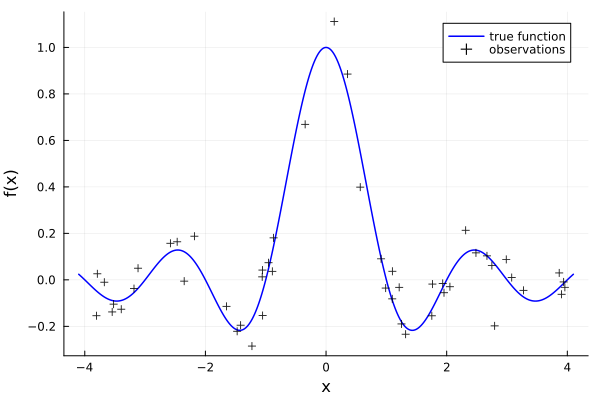

In [5]:
plot(xtest, f_true, linewidth = 1.5, label = "true function", color = :blue)
scatter!(xtrain, ytrain, alpha = 1, label = "observations", color = :black, marker = :cross)
xlabel!("x")
ylabel!("f(x)")


## Configure GP


In [7]:
gpcache = GPCache()
optimizer = Flux.AdaMax(0.01, (0.9, 0.999))

D = size(Xu[1], 1)
mean_fn = x -> 0.0
method = nothing

kernel_spec = :SE
independent_SE_lengthscales = true
kernel, θ_init, dim_θ = get_simple_kernel_and_params(
    D;
    kernel_spec = kernel_spec,
    num_SE = 1,
    num_SM = 0,
    independent_SE_lengthscales = independent_SE_lengthscales,
)
mode = :AN
state = Flux.setup(optimizer, θ_init)
;


## Setup Model


In [9]:
@model function gp_regression(y, x, Xu, θ, qv_params, qw_params)
    v ~ MvNormalWeightedMeanPrecision(qv_params...)
    w ~ GammaShapeRate(qw_params...)

    for i in eachindex(x)
        y[i] ~ UniSGP(x[i], v, w, θ)
    end
end

gp_constraints = @constraints begin
    q(v, w) = q(v)q(w)
end

@meta function GP_meta_inference(; Xu, θ)
    UniSGP() -> get_UniSGPMeta(
        D;
        method = method,
        mean_fn = mean_fn,
        kernel = kernel,
        kernel_spec = kernel_spec,
        mode = mode,
        independent_SE_lengthscales = independent_SE_lengthscales,
        operator = :fn,
        Xu = Xu,
        θ = θ,
    )
end

@initialization function gp_init(;qw_params)
    q(w) = GammaShapeRate(qw_params...)
end


gp_init (generic function with 1 method)

## Setup Inference


In [10]:
function my_free_energy(θ; iterations = 1, q_v, q_w)
    infer_result = infer(
        model = gp_regression(
            Xu = Xu,
            θ = θ,
            qv_params = BayesBase.params(q_v),
            qw_params = BayesBase.params(q_w),
        ),
        iterations = iterations,
        data = (y = ytrain, x = xtrain_vv),
        initialization = gp_init(
            qw_params = BayesBase.params(q_w),
        ),
        constraints = gp_constraints,
        returnvars = KeepLast(),
        meta = GP_meta_inference(Xu = Xu, θ = θ),
        free_energy = true,
    )

    return infer_result.free_energy[end], infer_result.posteriors[:v], infer_result.posteriors[:w]
end

function PerformInference(θ; iterations = 2, runs = 20, epochs = 50)
    FE_value = Float64[]
    q_v_ = Any[]
    q_w_ = Any[]
    θ_ = Any[]

    q_v = MvNormalWeightedMeanPrecision(mean_fn.(Xu), 50diageye(Nu))
    q_w = GammaShapeRate(1e-2, 1e-2)
    θ_optimal = deepcopy(θ)
    grad = similar(θ)

    meta_fn = get_UniSGPMeta(
        D;
        method = method,
        mean_fn = mean_fn,
        kernel = kernel,
        kernel_spec = kernel_spec,
        mode = mode,
        independent_SE_lengthscales = independent_SE_lengthscales,
        operator = :fn,
        Xu = Xu,
        θ = θ,
    )
    Lm_fn  = getLm_fn(meta_fn)
    Kxx_fn = getKxx_fn(meta_fn)
    Kxu_fn = getKxu_fn(meta_fn)

    for run in 1:runs
        fe, q_v, q_w = my_free_energy(θ_optimal; iterations = iterations, q_v = q_v, q_w = q_w)

        for epoch in 1:epochs
            grad_llh_default!(
                grad,
                θ_optimal;
                y_data = ytrain,
                x_y_data = xtrain_vv,
                x_ω_data = xtrain_vv,
                ω_data = nothing,
                q_v = q_v,
                q_w = q_w,
                q_Wg = nothing,
                method = method,
                kernel = kernel,
                Lm_fn = Lm_fn,
                Kxx_fn = Kxx_fn,
                Kxu_fn = Kxu_fn,
                mean_fn = mean_fn,
                Xu = Xu,
            )
            Flux.Optimise.update!(state, θ_optimal, grad)
        end

        push!(FE_value, fe)
        push!(q_v_, q_v)
        push!(q_w_, q_w)
        push!(θ_, deepcopy(θ_optimal))
    end

    return q_v_, q_w_, FE_value, θ_optimal, θ_
end


PerformInference (generic function with 1 method)

## Run Inference


In [16]:
q_v_, q_w_, FE_value, θ_optimal, θ_ = PerformInference(θ_init; iterations = 6, runs = 20, epochs = 50)

qv = q_v_[end]
qw = q_w_[end]

StatsFuns.softplus.(θ_optimal)


2-element Vector{Float64}:
 1.3549719227776267
 0.7026185034145063

## Plot Inference Results


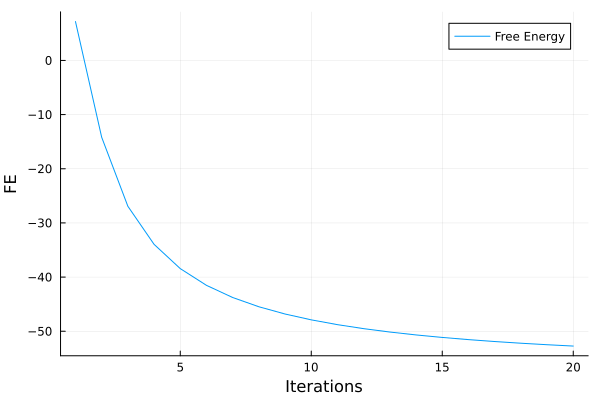

In [17]:
plot(FE_value, label = "Free Energy", xlabel = "Iterations", ylabel = "FE", legend = :topright)


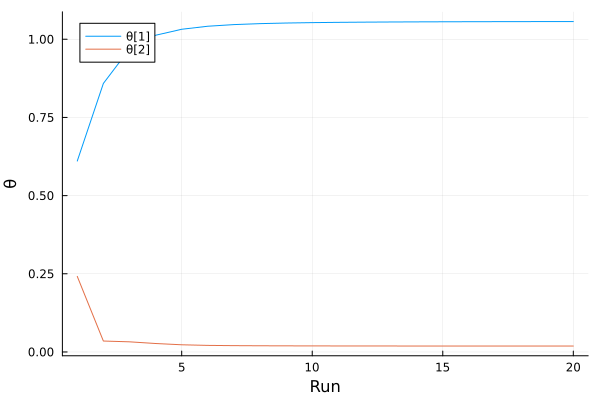

In [18]:
θ_matrix = hcat(θ_...)'
plot(θ_matrix, xlabel = "Run", ylabel = "θ", label = permutedims(["θ[$i]" for i in 1:size(θ_matrix, 2)]))


## Plot Prediction Results


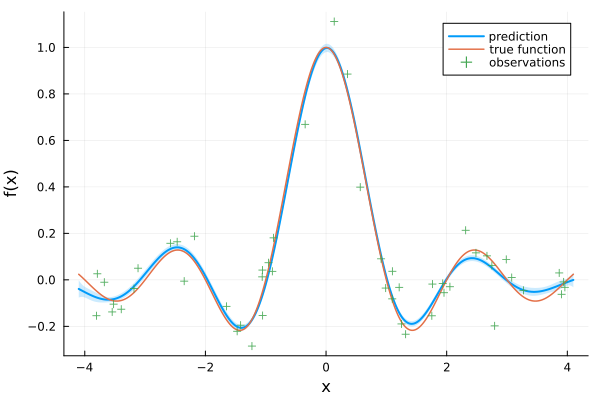

In [19]:
_means, _covs = predict_GP(
    m_in = xtest_vv,
    q_v = qv,
    q_θ = θ_optimal,
    meta = get_UniSGPMeta(
        D;
        method = method,
        mean_fn = mean_fn,
        kernel = kernel,
        kernel_spec = kernel_spec,
        mode = mode,
        independent_SE_lengthscales = independent_SE_lengthscales,
        operator = :fn,
        Xu = Xu,
        θ = θ_optimal,
    ),
)

predict_mean = [m isa Number ? m : m[1] for m in _means]
predict_var  = [C isa Number ? C : C[1, 1] for C in _covs]

plot(
    xtest,
    predict_mean,
    ribbon = sqrt.(predict_var),
    label = "prediction",
    linewidth = 2,
    fillalpha = 0.2,
)
plot!(xtest, f_true, linewidth = 1.5, label = "true function")
scatter!(xtrain, ytrain, alpha = 1, label = "observations", marker = :cross)
xlabel!("x")
ylabel!("f(x)")


## Measure Prediction Results


In [15]:
function SMSE(y_true, y_approx)
    N = length(y_true)
    mse = norm(y_true - y_approx)^2 / N
    return mse / var(y_true)
end

println("SMSE value of SGP node: ", SMSE(f_true, predict_mean))
println("FE_value start and finish: ", FE_value[1], " ", FE_value[end])
println("θ_optimal: ", θ_optimal)
println("θ_optimal (softplus): ", StatsFuns.softplus.(θ_optimal))


SMSE value of SGP node: 0.00537169368551716
FE_value start and finish: 8.014530140962052 -51.78230857566109
θ_optimal: [0.9104482885467584, -0.08592235143188359]
θ_optimal (softplus): [1.2485932806708713, 0.6511085524205469]
